# Booking cancellation — exploratory data analysis

Goal: understand the booking dataset and inform feature engineering for predicting whether an advance booking will be cancelled (`date_cancelled` non-null).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from config.pathing import PROJECT_ROOT

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Load data

In [2]:
raw = pd.read_csv(PROJECT_ROOT / "bookings.csv", low_memory=False)
print(f"Rows: {len(raw):,}  |  Columns: {len(raw.columns)}")
raw.head(3)

Rows: 19,383  |  Columns: 64


,resid,ref,book_owner,booked on,pid,property_name,arrival_date,departure_date,nights,custid,cust_email,cust_title,cust_fname,cust_lname,customer_notes,cust_phone,cust_fax,cust_street,cust_suburb,cust_city,cust_country,cust_postcode,cust_newsletter,cust_balance,date_cancelled,status,user_id,pax,unit_code,room_code,room_amount,extras_amount,misc_amount,tot_amount,pay_amount,inv_amount,madeby,comments,notes,room_notes,extra_notes,other_info,veh_reg,voucher,cust ref,balance,repeat_guest,linen,please select a site,milk,purpose of visit,do you require a gst invoice to be issued?,what will you sleep in?,length of campervan,dog registration,mode of your site,please enter the length (in metres) of chosen mode,please select your mode of camping,date of birth,milk preference,customer notes,fly buys card,dog breed,have you received the covid-19 vaccination?
0,28466203,18654,136bealey,2026-05-11 15:14:33.563887+12,11981,136 on Bealey,2026-05-11 14:00:00,2026-05-12 10:00:00,1,"18,163,964.00",cs_suppliers@agoda.com,NaN,Joe,Dickson,NaN,NaN,NaN,NaN,NaN,NaN,New Zealand,NaN,n,0,NaN,4,136bealey,2,Room 1,Queen Studio,78.85,0.00,0,78.85,78.85,0.00,136bealeyagoda,Agoda: AGO-658320375\r\nGuest Benefits: Free W...,NaN,NaN,NaN,NaN,NaN,AGO-658320375,NaN,0.00,n,NaN,NaN,NaN,NaN,n,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,28466041,18653,136bealey,2026-05-11 14:24:27.683557+12,11982,Abbey Motor Lodge,2026-05-20 14:00:00,2026-05-21 10:00:00,1,"18,163,867.00",lsherr.756776@guest.booking.com,NaN,Liz,Sherrington,NaN,+64 210 319 386,NaN,NaN,NaN,NaN,New Zealand,NaN,n,0,NaN,4,NaN,1,Room 12,Standard Studio,93.50,0.00,0,93.50,0.00,0.00,136bealeybookcom,BookingCom: BCOM-6504349193\r\nYou have receiv...,BCOM extra reservation info: \r\nBooker has a ...,NO SMOKING room requested;\r\n\nbooked rate: N...,NaN,NaN,NaN,BCOM-6504349193,NaN,93.50,n,NaN,NaN,NaN,NaN,n,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28465809,18652,136bealey,2026-05-11 13:23:04.023155+12,11982,Abbey Motor Lodge,2026-05-11 14:00:00,2026-05-12 10:00:00,1,"18,163,728.00",mpdw999fmt@m.expediapartnercentral.com,NaN,Julie Ann,Mapute,NaN,11 111111111,NaN,NaN,NaN,NaN,NaN,98119,n,0,NaN,4,136bealey,1,Room 03,Exec Queen Studio,117.37,0.00,0,117.37,117.37,0.00,136bealeyexpedia,Expedia: EXP-2457454500\r\nSource: Expedia (Ex...,Payment Method: VirtualCard\r\nPayment amount ...,Bedding:,NaN,NaN,NaN,EXP-2457454500,NaN,0.00,n,NaN,NaN,NaN,NaN,n,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Extra-request and sparse columns

Many columns are custom form fields (camping, pets, milk, etc.) with almost no data. Drop them before modelling, along with PII and address fields we will not use.

In [3]:
EXTRA_REQUEST_COLS = [
    "comments", "notes", "room_notes", "extra_notes", "other_info", "veh_reg",
    "cust ref", "repeat_guest", "linen", "please select a site", "milk",
    "purpose of visit", "do you require a gst invoice to be issued?",
    "what will you sleep in?", "length of campervan", "dog registration",
    "mode of your site",
    "please enter the length (in metres) of chosen mode",
    "please select your mode of camping", "milk preference", "customer notes",
    "fly buys card ", "dog breed", "have you received the covid-19 vaccination?",
    "date of birth",
]
PII_AND_ADDRESS_COLS = [
    "cust_postcode", "cust_city", "cust_suburb", "cust_street", "cust_fax",
    "cust_email", "cust_fname", "cust_lname", "cust_title", "cust_phone",
]
OTHER_DROP_COLS = [
    "pid", "user_id", "cust_newsletter", "cust_balance", "misc_amount",
    "inv_amount",
]

extra_null_pct = raw[EXTRA_REQUEST_COLS].isna().mean().mul(100).sort_values(ascending=False)
print("Null % for extra-request columns (top 10):")
display(extra_null_pct.head(10).to_frame("null_%"))

Null % for extra-request columns (top 10):


,null_%
linen,100.00
please enter the length (in metres) of chosen mode,100.00
mode of your site,100.00
length of campervan,100.00
dog registration,100.00
what will you sleep in?,100.00
purpose of visit,100.00
milk,100.00
please select a site,100.00
fly buys card,100.00


In [4]:
DROP_COLS = EXTRA_REQUEST_COLS + PII_AND_ADDRESS_COLS + OTHER_DROP_COLS
df = raw.drop(columns=DROP_COLS, errors="ignore").copy()

df["is_cancelled"] = df["date_cancelled"].notna()
df["has_customer_notes"] = df["customer_notes"].notna()
df["has_voucher"] = df["voucher"].notna()

print(f"Modelling frame: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.columns.tolist()

Modelling frame: 19,383 rows × 26 columns


['resid',
 'ref',
 'book_owner',
 'booked on',
 'property_name',
 'arrival_date',
 'departure_date',
 'nights',
 'custid',
 'customer_notes',
 'cust_country',
 'date_cancelled',
 'status',
 'pax',
 'unit_code',
 'room_code',
 'room_amount',
 'extras_amount',
 'tot_amount',
 'pay_amount',
 'madeby',
 'voucher',
 'balance',
 'is_cancelled',
 'has_customer_notes',
 'has_voucher']

## Data quality

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = (
    pd.DataFrame({"missing": missing, "missing_%": missing_pct})
    .query("missing > 0")
    .sort_values("missing", ascending=False)
)
missing_summary

,missing,missing_%
customer_notes,18357,94.70
date_cancelled,15957,82.30
cust_country,8003,41.30
voucher,4410,22.80
unit_code,3444,17.80
custid,763,3.90
madeby,455,2.30
room_code,15,0.10


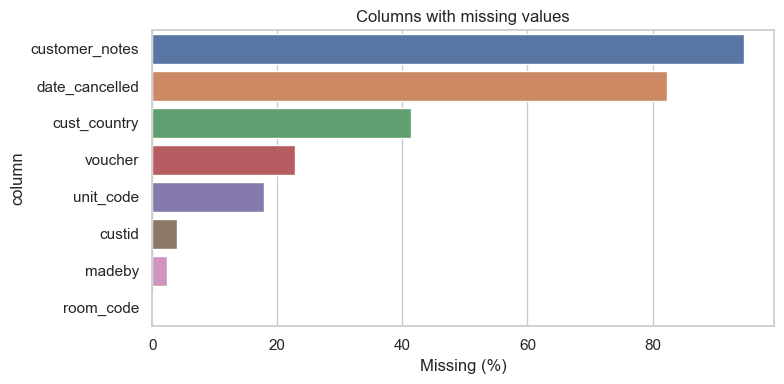

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=missing_summary.reset_index(names="column"),
    y="column",
    x="missing_%",
    hue="column",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Missing (%)")
ax.set_title("Columns with missing values")
plt.tight_layout()

In [7]:
print(f"Fully duplicate rows: {df.duplicated().sum():,}")
print(f"Unique reservations (resid): {df['resid'].nunique():,}")
df.info()

Fully duplicate rows: 6
Unique reservations (resid): 18,203
<class 'pandas.DataFrame'>
RangeIndex: 19383 entries, 0 to 19382
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   resid               19383 non-null  int64  
 1   ref                 19383 non-null  int64  
 2   book_owner          19383 non-null  str    
 3   booked on           19383 non-null  str    
 4   property_name       19383 non-null  str    
 5   arrival_date        19383 non-null  str    
 6   departure_date      19383 non-null  str    
 7   nights              19383 non-null  int64  
 8   custid              18620 non-null  float64
 9   customer_notes      1026 non-null   str    
 10  cust_country        11380 non-null  str    
 11  date_cancelled      3426 non-null   str    
 12  status              19383 non-null  int64  
 13  pax                 19383 non-null  int64  
 14  unit_code           15939 non-null  str    
 15  room

In [8]:
cardinality = df.nunique().sort_values(ascending=False).to_frame("n_unique")
cardinality

,n_unique
resid,18203
ref,15264
custid,14606
voucher,14053
booked on,13649
tot_amount,3756
room_amount,3553
pay_amount,3536
departure_date,2217
arrival_date,2197


In [9]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

print(f"Numeric ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
df[numeric_cols].describe().T

Numeric (11): ['resid', 'ref', 'nights', 'custid', 'status', 'pax', 'room_amount', 'extras_amount', 'tot_amount', 'pay_amount', 'balance']
Categorical (15): ['book_owner', 'booked on', 'property_name', 'arrival_date', 'departure_date', 'customer_notes', 'cust_country', 'date_cancelled', 'unit_code', 'room_code', 'madeby', 'voucher', 'is_cancelled', 'has_customer_notes', 'has_voucher']


,count,mean,std,min,25%,50%,75%,max
resid,"19,383.00","22,717,535.28","4,339,672.45","17,591,043.00","17,602,569.50","22,717,731.00","27,085,660.00","28,466,203.00"
ref,"19,383.00","10,399.38","4,393.47","1,001.00","6,718.00","9,799.00","14,166.50","18,654.00"
nights,"19,383.00",3.78,12.81,1.00,1.00,1.00,2.00,373.00
custid,"18,620.00","13,661,150.13","4,104,126.29",0.00,"10,622,891.75","13,794,656.00","17,157,075.00","18,163,964.00"
status,"19,383.00",4.72,1.59,2.00,4.00,4.00,4.00,15.00
pax,"19,383.00",2.14,0.94,0.00,2.00,2.00,2.00,7.00
room_amount,"19,383.00",490.00,"2,599.84",0.00,79.05,123.93,250.00,"175,584.00"
extras_amount,"19,383.00",12.39,132.29,"-1,200.00",0.00,0.00,0.00,"3,036.00"
tot_amount,"19,383.00",502.38,"2,647.34",-546.00,79.05,124.00,250.00,"175,584.00"
pay_amount,"19,383.00",692.44,"3,757.97",-956.10,0.00,117.05,247.86,"93,830.00"


## Target: cancellation

Cancellation aligns with non-null `date_cancelled`. Status codes `8`, `7`, `14`, and `15` correspond to cancelled bookings; status `4` is active.

In [10]:
cancel_rate = df["is_cancelled"].mean()
print(f"Cancellation rate: {cancel_rate:.1%} ({df['is_cancelled'].sum():,} / {len(df):,})")

status_cancel = pd.crosstab(df["status"], df["is_cancelled"], margins=True)
status_cancel

Cancellation rate: 17.7% (3,426 / 19,383)


is_cancelled,False,True,All
status,,,
2,8,0,8
3,86,0,86
4,15840,0,15840
7,0,1,1
8,0,3402,3402
12,15,0,15
13,8,0,8
14,0,10,10
15,0,13,13


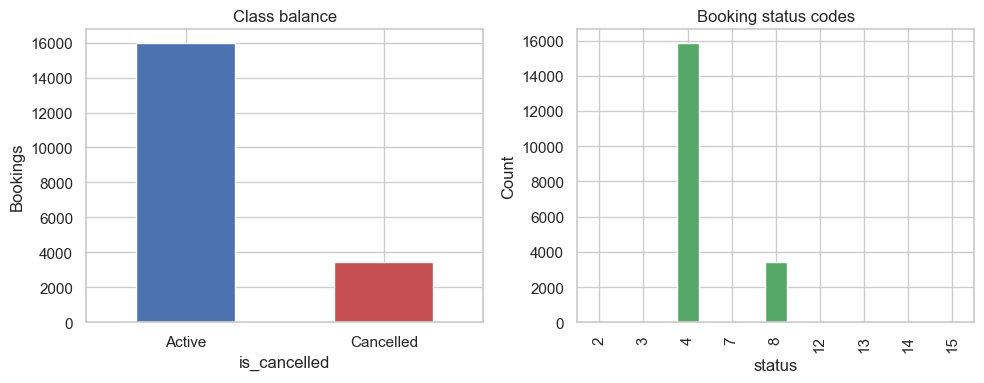

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["is_cancelled"].value_counts().rename({False: "Active", True: "Cancelled"}).plot(
    kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"], rot=0
)
axes[0].set_title("Class balance")
axes[0].set_ylabel("Bookings")

df["status"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#55a868")
axes[1].set_title("Booking status codes")
axes[1].set_xlabel("status")
axes[1].set_ylabel("Count")

plt.tight_layout()

## Categorical features

In [12]:
for col in ["property_name", "madeby", "room_code", "cust_country"]:
    print(f"\n=== {col} ({df[col].nunique()} unique) ===")
    display(df[col].value_counts(dropna=False).head(10))


=== property_name (2 unique) ===


property_name
136 on Bealey        10575
Abbey Motor Lodge     8808
Name: count, dtype: int64


=== madeby (10 unique) ===


madeby
136bealeybookcom     5810
Import               4964
136bealey            3408
136bealeyexpedia     2222
136bealeyagoda       1503
staffs                861
NaN                   455
luo                   116
136bealeyreconlin      40
136bealeyairbnb1        3
Name: count, dtype: int64


=== room_code (17 unique) ===


room_code
Queen Studio                                       4903
Standard Studio                                    2908
136                                                2735
dummy                                              2288
Twin Studio                                        1311
Executive Twin Studio                              1024
One Bedroom Family Apartment                        927
Two-Bedroom Apartment                               723
One Bedroom Apartment with Queen and Single bed     612
King Kitchen studio                                 584
Name: count, dtype: int64


=== cust_country (64 unique) ===


cust_country
New Zealand                 9488
NaN                         8003
Australia                    793
United States of America     197
United Kingdom               147
Malaysia                      81
Germany                       76
China                         68
Singapore                     50
Japan                         47
Name: count, dtype: int64

In [13]:
def cancellation_rate_by(series: pd.Series, min_count: int = 50) -> pd.DataFrame:
    rates = (
        df.assign(_group=series.fillna("(missing)"))
        .groupby("_group", observed=True)["is_cancelled"]
        .agg(count="count", cancel_rate="mean")
        .query("count >= @min_count")
        .sort_values("cancel_rate", ascending=False)
    )
    rates["cancel_rate"] = (rates["cancel_rate"] * 100).round(1)
    return rates

print("Cancellation rate by property:")
display(cancellation_rate_by(df["property_name"], min_count=1))

print("\nCancellation rate by booking channel (madeby, top channels):")
display(cancellation_rate_by(df["madeby"]).head(12))

Cancellation rate by property:


,count,cancel_rate
_group,,
Abbey Motor Lodge,8808,17.90
136 on Bealey,10575,17.50



Cancellation rate by booking channel (madeby, top channels):


,count,cancel_rate
_group,,
136bealeybookcom,5810,30.30
(missing),455,29.20
staffs,861,23.00
136bealeyexpedia,2222,20.20
136bealey,3408,15.80
luo,116,10.30
Import,4964,5.00
136bealeyagoda,1503,4.70


In [14]:
room_rates = cancellation_rate_by(df["room_code"], min_count=100)
print("Room types with ≥100 bookings (by cancellation rate):")
display(room_rates)

print("\nData-quality flags in room_code:", df.loc[df["room_code"].isin(["dummy", "136"]), "room_code"].value_counts().to_dict())

Room types with ≥100 bookings (by cancellation rate):


,count,cancel_rate
_group,,
Interconnecting Room,298,35.60
One Bedroom Family Apartment,927,30.10
Twin Studio,1311,27.80
Two-Bedroom Apartment,723,27.70
Exec Queen Studio,285,27.40
Twin Kitchen Studio,242,24.40
Queen Family Triple,228,24.10
King Kitchen studio,584,22.30
One Bedroom Apartment with Queen and Single bed,612,20.90



Data-quality flags in room_code: {'136': 2735, 'dummy': 2288}


## Numerical features

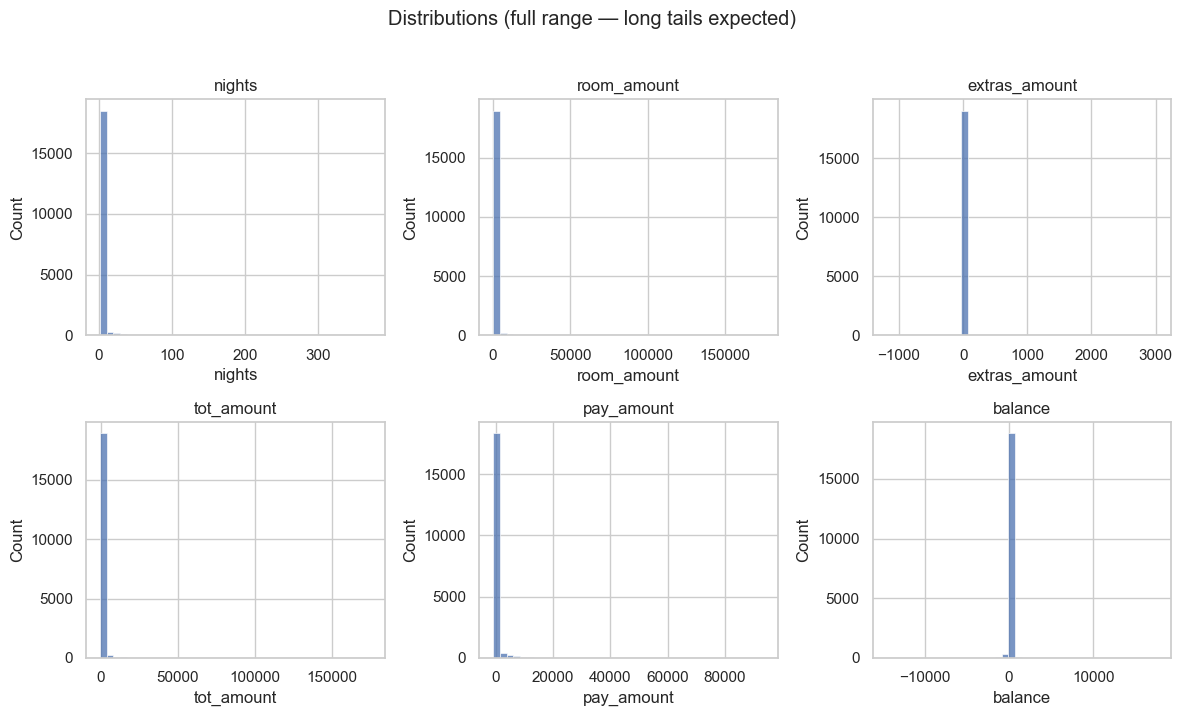

In [15]:
amount_cols = ["nights", "room_amount", "extras_amount", "tot_amount", "pay_amount", "balance"]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, amount_cols):
    sns.histplot(data=df, x=col, bins=40, ax=ax, color="#4c72b0")
    ax.set_title(col)
plt.suptitle("Distributions (full range — long tails expected)", y=1.02)
plt.tight_layout()

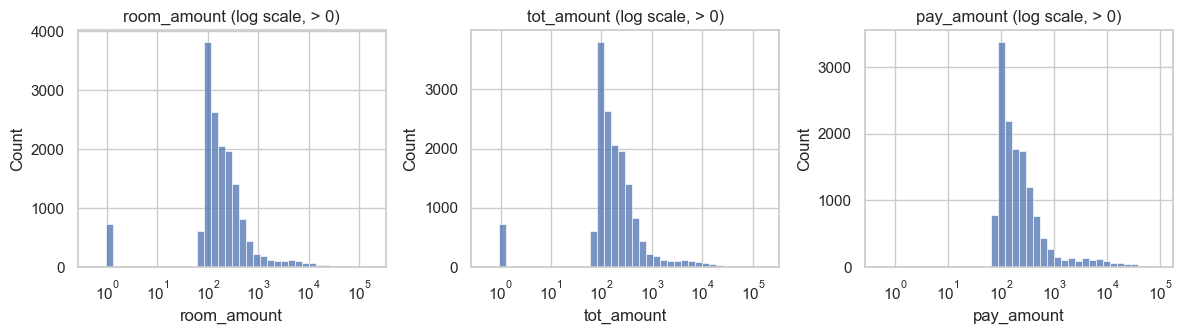

In [16]:
log_amount_cols = ["room_amount", "tot_amount", "pay_amount"]
plot_df = df[log_amount_cols].clip(lower=0).replace(0, pd.NA)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, log_amount_cols):
    sns.histplot(data=plot_df.dropna(subset=[col]), x=col, bins=40, ax=ax, log_scale=True)
    ax.set_title(f"{col} (log scale, > 0)")
plt.tight_layout()

C:\Users\jocac\AppData\Local\Temp\ipykernel_31364\255473952.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Active", "Cancelled"])
C:\Users\jocac\AppData\Local\Temp\ipykernel_31364\255473952.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Active", "Cancelled"])


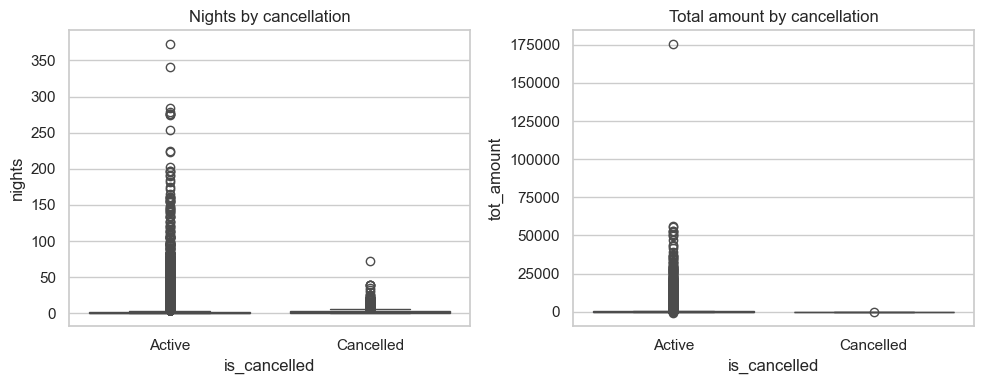

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x="is_cancelled", y="nights", ax=axes[0])
axes[0].set_xticklabels(["Active", "Cancelled"])
axes[0].set_title("Nights by cancellation")

sns.boxplot(data=df, x="is_cancelled", y="tot_amount", ax=axes[1])
axes[1].set_xticklabels(["Active", "Cancelled"])
axes[1].set_title("Total amount by cancellation")
plt.tight_layout()

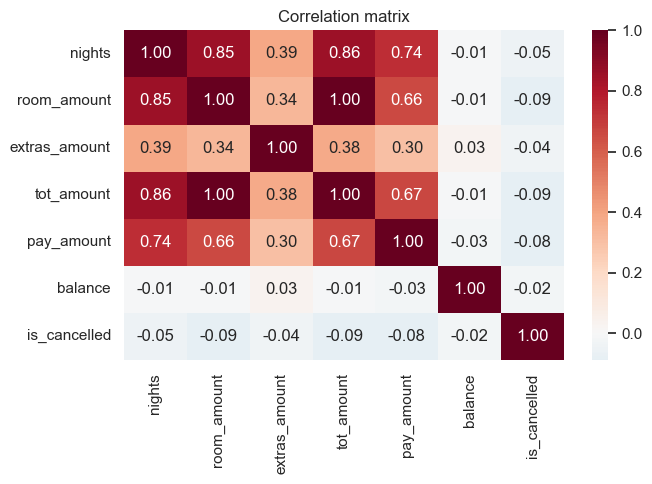

In [18]:
corr_cols = ["nights", "room_amount", "extras_amount", "tot_amount", "pay_amount", "balance", "is_cancelled"]
corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()

## Data issues and constants

| Issue | Detail |
|-------|--------|
| `book_owner` | Single value (`136bealey`) — no predictive signal |
| `resid` / `ref` | High-cardinality IDs — exclude from features or hash |
| `room_code` | Contains `dummy` and `136` placeholders; 15 missing |
| Amounts | Negative `extras_amount`, `tot_amount`, `pay_amount` exist (refunds/adjustments) |
| `nights` | Max 373 — verify outliers vs long stays |
| Duplicates | 42 fully duplicate rows — drop before training |
| `madeby` | Channel mix differs by property (e.g. Abbey vs 136 on Bealey) |

In [19]:
print("book_owner:", df["book_owner"].unique())
print("Negative amounts:", {c: (df[c] < 0).sum() for c in amount_cols if c in df.columns})
print("Long stays (nights > 30):", (df["nights"] > 30).sum())

book_owner: <ArrowStringArray>
['136bealey']
Length: 1, dtype: str
Negative amounts: {'nights': np.int64(0), 'room_amount': np.int64(0), 'extras_amount': np.int64(55), 'tot_amount': np.int64(2), 'pay_amount': np.int64(9), 'balance': np.int64(445)}
Long stays (nights > 30): 416


## Planned preprocessing (for modelling)

| Column | Plan |
|--------|------|
| `custid` | Impute missing with synthetic unique IDs or treat as "unknown guest" |
| `customer_notes` | Use `has_customer_notes` flag (already derived) |
| `cust_country` | Default missing to `NZ` (majority market) |
| `date_cancelled` | Leakage — use only to derive target; drop from features |
| `unit_code` | Impute from `room_code` mapping where possible |
| `room_code` | Impute rare/missing; map or drop `dummy` / `136` |
| `madeby` | Impute missing with property default channel |
| `voucher` | Use `has_voucher` flag (already derived) |
| Dates | Parse `booked on`, `arrival_date`, `departure_date`; engineer lead time |

## Summary

- **~19.4k** bookings across **two properties**; **~17.7%** cancelled.
- **22** modelling columns after dropping sparse form fields and PII.
- Strong predictors to explore: **booking channel** (`madeby`), **property**, **room type**, **lead time** (from dates), and **payment/balance** fields.
- **Next steps:** parse datetimes, build train/validation split (time-based), encode categoricals, and baseline classifier with class imbalance handled.

## Data Cleaning ##
- Impute motel direct booking as default for null madeby
- Remove null room_codes
- No dupes to remove as seen via EDA

In [20]:
df = df[df['room_code'].notna()]
df['room_code'].isna().sum()

np.int64(0)

Impute 136bealey as default for null madeby channel values

In [21]:
df['madeby'] = df['madeby'].fillna('136bealey')
df['madeby'].isna().sum()


np.int64(0)

Combine motel direct channel bookings under 136bealey

In [22]:
motel_direct_channel = ['staffs', 'luo', 'alanaga', '136bealeyairbnb1', '136bealeyreconlin']
df.loc[df['madeby'].isin(motel_direct_channel), 'madeby'] = '136bealey' 
df['madeby'].value_counts()

madeby
136bealeybookcom    5803
Import              4964
136bealey           4884
136bealeyexpedia    2221
136bealeyagoda      1496
Name: count, dtype: int64

## Feature engineering

Parse dates from `raw` (original CSV strings) so mixed formats parse correctly and cells are safe to re-run.


Binary encode property_name and is_domestic guest

In [23]:

df['is_domestic'] = (df['cust_country'] == 'New Zealand') | (df['cust_country'].isna())
df['is_domestic'].value_counts()

is_domestic
True     17481
False     1887
Name: count, dtype: int64

In [24]:
df['is_136_motel'] = (df['property_name'] == '136 on Bealey')
df['is_136_motel'].value_counts()

is_136_motel
True     10560
False     8808
Name: count, dtype: int64

## Create look-up table for room_code ##
- includes columns property_name, unit_code, room_code (modal room_type)
- Property_name, unit_code pairs should be unique

In [25]:
# Correct lookup table (merge on keys — order-independent; compare to room_code_mapping above)
PLACEHOLDER_ROOM = (
    ((df["property_name"] == "Abbey Motor Lodge") & (df["room_code"] == "dummy"))
    | ((df["property_name"] == "136 on Bealey") & (df["room_code"] == "136"))
)

modal_by_unit = (
    df.loc[~PLACEHOLDER_ROOM]
    .groupby(["property_name", "unit_code"])["room_code"]
    .apply(lambda s: s.mode().iloc[0])
    .reset_index(name="modal_room_code")
)

# One row per real unit (drop NaN unit_code from unique())
units_table = (
    df.loc[df["unit_code"].notna(), ["property_name", "unit_code"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# abbey room 12 @ 136 on Bealey: no valid rows after filter → alias to Room 12 for lookup
def lookup_unit(row):
    if row["property_name"] == "136 on Bealey" and row["unit_code"] == "abbey room 12":
        return "Room 12"
    return row["unit_code"]

units_table["lookup_unit"] = units_table.apply(lookup_unit, axis=1)

room_lookup_v2 = units_table.merge(
    modal_by_unit.rename(columns={"unit_code": "lookup_unit"}),
    on=["property_name", "lookup_unit"],
    how="left",
)

print(f"units in table: {len(units_table)}")
print(f"rows with modal: {room_lookup_v2['modal_room_code'].notna().sum()}")
print(f"still missing modal:\n{room_lookup_v2.loc[room_lookup_v2['modal_room_code'].isna()]}")

room_lookup_v2.sort_values(["property_name", "unit_code"])

units in table: 45
rows with modal: 45
still missing modal:
Empty DataFrame
Columns: [property_name, unit_code, lookup_unit, modal_room_code]
Index: []


,property_name,unit_code,lookup_unit,modal_room_code
32,136 on Bealey,Dummy2,Dummy2,Queen Studio
42,136 on Bealey,Dummy3,Dummy3,Queen Studio
43,136 on Bealey,Dummy4,Dummy4,Queen Studio
0,136 on Bealey,Room 1,Room 1,Queen Studio
12,136 on Bealey,Room 10,Room 10,Queen Studio
18,136 on Bealey,Room 11,Room 11,Queen Studio
26,136 on Bealey,Room 12,Room 12,Queen Studio
27,136 on Bealey,Room 13,Room 13,Queen Studio
22,136 on Bealey,Room 14,Room 14,Queen Studio
28,136 on Bealey,Room 15,Room 15,Queen Studio


Impute dummy room_code for abbey and 136 room_code for 136 via lookup table 

In [26]:
# filter placeholder rooms and make a copy df for only placeholders
ph_df = df.loc[PLACEHOLDER_ROOM].copy()
# merge to get placeholders' rooms' modal room_code with lookup df
ph_impute = ph_df.merge(room_lookup_v2, on=['property_name', 'unit_code'], how='left')
# re-align indexes to impute the correct rows
ph_impute.index = ph_df.index
# impute placeholder rooms with modal room_code
df.loc[PLACEHOLDER_ROOM, 'room_code'] = ph_impute['modal_room_code']
# impute placeholders with null unit code with 'unknown' as room_code
df.loc[PLACEHOLDER_ROOM & df['unit_code'].isna(), 'room_code'] = 'Unknown'

## Historical average rate per room_code ##
- First filter out cancelled bookings that lack payment amount
- Calculate payment amount / nights as room_rate
- Group by room_code and aggregate average room_rate amongst that group
- create a dictionary as a lookup where key is room_code and value is average historical room_rate
- impute lookup room_rate value for every cancelled booking that lacks payment value
- leave bookings that have a valid room_rate

In [34]:
rate_df = df.loc[(df['is_cancelled'] == 0) & (df['room_amount'] > 0.0), ['ref', 'room_code', 'nights', 'pay_amount', 'tot_amount', 'room_amount']].copy()
rate_mask = ((rate_df['room_amount'] > 0) & (rate_df['nights'] > 0))
rate_df['room_rate'] = rate_df.loc[rate_mask, 'room_amount'] / rate_df.loc[rate_mask, 'nights']
# calculate aggregate average room_rate per room_code
historical_rates = (rate_df
                    .loc[rate_df['room_rate'] != 0.0]
                    .groupby('room_code')['room_rate']
                    .apply(lambda x: x.median())
                    .reset_index(name="historical_room_rate")
                    )

historical_rates.loc[len(historical_rates)] = {
    'room_code': 'Unknown', 
    'historical_room_rate': historical_rates['historical_room_rate'].mean()
    }
print(historical_rates)
print(len(rate_df))

                                          room_code  historical_room_rate
0                                    3 Bedroom Unit                260.00
1                                 Exec Queen Studio                121.50
2                             Executive Twin Studio                121.50
3                              Interconnecting Room                231.30
4                               King Kitchen studio                120.00
5                                   King Spa Studio                123.00
6   One Bedroom Apartment with Queen and Single bed                158.40
7                      One Bedroom Family Apartment                137.70
8                    Private Room Shared Facilities                110.00
9                               Queen Family Triple                145.40
10                                     Queen Studio                103.50
11                                  Standard Studio                100.98
12                              Twin K

- Create room_rate column and assign pre-calculated room rates where available
- Rooms that did not have room_amount stay null

In [35]:

# merge impute historical rate to the cancelled 

import numpy as np
# instantiate a column of null values for room_rate
df['room_rate'] = np.nan
# assign all of rate_df to room_rate column based on matching indices
df.loc[rate_df.index, 'room_rate'] = rate_df['room_rate']
print(df['room_rate'].isna().sum())
print(len(rate_df)) 
print(len(df)) 
# rate_impute.index = df.index 


3664
15704
19368


NULL room_rate values use lookup value based on room_code

In [36]:
df['room_rate']
historical_impute = df.loc[df['room_rate'].isna()].merge(historical_rates, on='room_code', how='left')
historical_impute.index = df.loc[df['room_rate'].isna()].index
df.loc[df['room_rate'].isna(), 'room_rate'] = historical_impute['historical_room_rate']
df['room_rate'].isna().sum()

np.int64(0)

## Aggregate booking level features ##
- Average price per person 
- Total rooms per booking
- Total guests per booking

In [37]:
df['room_revenue'] = df['room_rate'] * df['nights'] # helper value
df['person_nights'] = df['pax'] * df['nights'] # helper value

# booked on or lead_date needs revisiting for whether should be calculated at room level or booking level df
# need to figure out how to handle stay duration since not all bookings have a single consistent stay duration for multi-room 
# decide whether to one hot encode room_code which would add 14 columns eg booked_double_queen
booking_aggregates = df.groupby(['ref', 'is_136_motel', 'arrival_date', 'departure_date'], as_index=False).aggregate(
    madeby=('madeby', 'first'), # booking channel as a string for onehot later
    booked_on=('booked on', 'min'), # earliest booking time
    has_customer_notes=('has_customer_notes', 'first'),
    is_domestic=('is_domestic', 'first'),
    has_voucher=('has_voucher', 'first'),
    total_rooms=('ref', 'size'),
    total_guests=('pax', 'sum'),
    total_room_revenue=('room_revenue', 'sum'), # total booking value from room prices only
    person_nights=('person_nights', 'sum'), # helper, can be deleted for performance
    average_room_rate=('room_rate', 'mean'),
    is_cancelled=('is_cancelled', 'min') # target column
)

booking_aggregates['average_price_pp'] = booking_aggregates['total_room_revenue'] / booking_aggregates['person_nights']

### Engineer lead time ###

In [61]:
# Parse dates from booking_aggregates columns (NOT df) — df rows do not align 1:1 with booking rows
booking_aggregates["booked_on"] = pd.to_datetime(booking_aggregates["booked_on"], errors="coerce", utc=True, format="mixed")
booking_aggregates["arrival_date"] = pd.to_datetime(booking_aggregates["arrival_date"], errors="coerce", utc=True, format="mixed")
booking_aggregates["departure_date"] = pd.to_datetime(booking_aggregates["departure_date"], errors="coerce", utc=True, format="mixed")

booking_aggregates["lead_time"] = booking_aggregates["arrival_date"] - booking_aggregates["booked_on"]
booking_aggregates["lead_time_days"] = round(booking_aggregates["lead_time"].dt.total_seconds() / 86_400, ndigits=2)

print(f"lead_time_days — min: {booking_aggregates['lead_time_days'].min():.2f}, median: {booking_aggregates['lead_time_days'].median():.2f}, max: {booking_aggregates['lead_time_days'].max():.2f}")
booking_aggregates.loc[booking_aggregates["ref"] == 5763, ["ref", "booked_on", "arrival_date", "lead_time_days"]].head()

lead_time_days — min: -374.46, median: 10.29, max: 2934.08


,ref,booked_on,arrival_date,lead_time_days
2797,5763,2020-03-30 11:00:00+00:00,2020-04-15 14:00:00+00:00,16.12
2798,5763,2019-07-09 12:00:00+00:00,2019-07-11 14:00:00+00:00,2.08


#### Drop bookings with invalid booking time ####

In [78]:
before = len(booking_aggregates)
booking_aggregates = booking_aggregates[booking_aggregates["lead_time_days"] >= 0].copy()
booking_aggregates['lead_time_days'] = booking_aggregates['lead_time_days'].clip(upper=525.00)
print(f"Dropped {before - len(booking_aggregates)} bookings with invalid lead_time_days")

Dropped 0 bookings with invalid lead_time_days


## One Hot Encode ##

- Madeby (Booking Channel)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

OH_encoder = OneHotEncoder()
OH_encoder.fit_transform()
booking_aggregates['madeby']

<ArrowStringArray>
['Import', '136bealey', '136bealeybookcom', '136bealeyexpedia',
 '136bealeyagoda']
Length: 5, dtype: str

In [82]:
booking_aggregates.columns

Index(['ref', 'is_136_motel', 'arrival_date', 'departure_date', 'madeby',
       'booked_on', 'has_customer_notes', 'is_domestic', 'has_voucher',
       'total_rooms', 'total_guests', 'total_room_revenue', 'person_nights',
       'average_room_rate', 'is_cancelled', 'average_price_pp', 'lead_time',
       'lead_time_days'],
      dtype='str')

## Training the model ##

In [85]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, precision_score

In [83]:
# Drop untrainable features
final_df = booking_aggregates.drop(['ref', 'booked_on', 'arrival_date',
'madeby', 'departure_date', 'lead_time'], axis=1)
final_df.columns

Index(['is_136_motel', 'has_customer_notes', 'is_domestic', 'has_voucher',
       'total_rooms', 'total_guests', 'total_room_revenue', 'person_nights',
       'average_room_rate', 'is_cancelled', 'average_price_pp',
       'lead_time_days'],
      dtype='str')

In [84]:
# drop target from X
X_features = final_df.drop(['is_cancelled'], axis=1)
Y_target = final_df['is_cancelled']
print(len(X_features.columns))

11


In [86]:
X_train, X_test, Y_train, Y_test = train_test_split(X_features, Y_target, test_size=0.2, stratify=Y_target)
mymodel = RandomForestClassifier(random_state=67, n_jobs=-2)
xgmodel = XGBClassifier(n_jobs=-2, random_state = 67)
mymodel.fit(X_train, Y_train)
xgmodel.fit(X_train, Y_train)
predictions = mymodel.predict(X_test)
xgpredictions = xgmodel.predict(X_test)
f1score = f1_score(Y_test, predictions)
recall = recall_score(Y_test, predictions)
f1xg = f1_score(Y_test, xgpredictions)
f1recall = recall_score(Y_test, xgpredictions)
print(f1score)
print(recall)
print(f1xg)
print(f1recall)

0.8699324324324325
0.8498349834983498
0.9223221586263287
0.9306930693069307


In [44]:
# df['room_rate'] = rate_impute['room_rate']
# merge impute df with historical_rates where room_rates is 0
# rate_df.loc[rate_df['room_amount'] == 0.0].merge(rate_df, on=['ref'])
# rate_df.loc[rate_df['room_amount'] == 0.0] = rate_df
# print(len(rate_df[rate_df['room_rate'] == 0.0]))

In [45]:
# # Always parse from raw strings — df["booked on"] may already be datetime/NaT if this cell was run before
# df["booked on"] = pd.to_datetime(raw["booked on"], errors="coerce", utc=True, format="mixed")
# df["arrival_date"] = pd.to_datetime(raw["arrival_date"], errors="coerce", utc=True, format="mixed")
# df["departure_date"] = pd.to_datetime(raw["departure_date"], errors="coerce", utc=True, format="mixed")

# df["lead_time"] = df["arrival_date"] - df["booked on"]
# df["lead_time_days"] = df["lead_time"].dt.total_seconds() / 86_400

# print(f"lead_time_days — min: {df['lead_time_days'].min():.2f}, median: {df['lead_time_days'].median():.2f}, max: {df['lead_time_days'].max():.2f}")
# df.loc[df["ref"] == 5763, ["ref", "booked on", "arrival_date", "lead_time_days"]].head()


In [46]:
# df.loc[df['lead_time_days'] <= 0].head()

In [48]:
# print(df.columns)

In [49]:
# filter = (df['room_code'] == 'dummy')
# df[filter]['property_name'].unique() 
# dummy_rooms_df = df[filter]

In [50]:
# dummy_rooms_df['unit_code'].unique()

In [51]:
# abbey_dummy = df[df['room_code'] == 'dummy']
# len(abbey_dummy[abbey_dummy['unit_code'] == 'Residence'])

In [52]:
# df[filter].head()

## Add one-hot-encodings ##

In [53]:
# df.loc[df['madeby'] == '136bealeyairbnb1']

In [54]:
# df['room_code'].unique()

## Feature engineering ##
- price per night per person
- average room rate
- number of rooms by aggregating the total count of rows under one ref
- most cancelled bookings have no info for the room rate of the original booking so impute with average rate of the      booked room
- 

In [59]:
# final_df.columns